# PoC-3 — controlled CWT/gate ablation against the PoC-1 temporal expert

This notebook isolates the contribution of a complementary CWT expert and a
learned disagreement gate under the same train/validation/test protocol used
by PoC-1. The temporal CNN architecture and its training configuration are
kept at the PoC-1 values.

Protocol: `Tr0.mat` for fitting, `Va0.mat` for checkpoint/threshold/meta-model
selection, and `Te0.mat` for one final locked evaluation. `Te1.mat` and
`Te2.mat` are never loaded. The gate is trained from cross-fitted predictions
on `Tr0.mat`, so it never learns from in-sample expert predictions.

## Controlled hypotheses

- H1: CWT adds complementary information over the PoC-1 temporal expert.
- H2: a conservative gate improves the temporal expert on locked `Te0`.
- H3: the gate does not give up the CWT expert's individual performance.

The overall verdict is `GO` only if the gate improves both individual experts
with a positive paired-bootstrap lower bound. This makes the decision stricter
than merely beating a weak reference.

In [1]:
import gc
import json
import math
import os
import random
import struct
import subprocess
import sys
import time
from collections import Counter
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display
from scipy.io import loadmat
from scipy.stats import binomtest
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, average_precision_score, brier_score_loss, confusion_matrix, f1_score, matthews_corrcoef, precision_score, recall_score, roc_auc_score
from sklearn.model_selection import StratifiedKFold, train_test_split
from sklearn.neural_network import MLPClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
import torch
from torch import nn
from torch.utils.data import DataLoader, Dataset

PROJECT_ROOT = Path.cwd().resolve()
while PROJECT_ROOT != PROJECT_ROOT.parent:
    if (PROJECT_ROOT / 'poc' / 'experiments' / 'poc.ipynb').is_file() and (PROJECT_ROOT / 'data' / 'datasets.yaml').is_file():
        break
    PROJECT_ROOT = PROJECT_ROOT.parent
if not ((PROJECT_ROOT / 'poc' / 'experiments' / 'poc.ipynb').is_file() and (PROJECT_ROOT / 'data' / 'datasets.yaml').is_file()):
    raise RuntimeError('Run this notebook from the repository root.')

CATALOG_ROOT_VALUE = os.environ.get('PD_DATASETS_CATALOG_ROOT')
if not CATALOG_ROOT_VALUE:
    raise RuntimeError('Set PD_DATASETS_CATALOG_ROOT to the external datasets_catalog.')
CATALOG_ROOT = Path(CATALOG_ROOT_VALUE).expanduser().resolve()
DATASET_ID, DATASET_VERSION = 'engineering-partial-discharge-noise-signals', 'v1'
DATASET_ROOT = CATALOG_ROOT / 'data' / 'raw' / 'dataset-pd-noise'
RESULT_DIR = PROJECT_ROOT / 'poc' / 'results'
RESULT_DIR.mkdir(parents=True, exist_ok=True)
SEED, MAX_EPOCHS, PATIENCE, BATCH_SIZE, INFERENCE_BATCH_SIZE = 42, 20, 5, 128, 512
TORCH_THREADS, N_GATE_FOLDS, N_BOOTSTRAP, BOOTSTRAP_SEED = 2, 5, 2000, 20260902
DEVICE = torch.device('cpu')
ALLOWED_PARTITIONS = ('Tr0.mat', 'Va0.mat', 'Te0.mat')
EXPECTED_COUNTS = {'Tr0.mat': {0: 6130, 1: 6130}, 'Va0.mat': {0: 1533, 1: 1533}, 'Te0.mat': {0: 22985, 1: 22985}}
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED); torch.set_num_threads(TORCH_THREADS)

def git_commit():
    try:
        return subprocess.check_output(['git', '-C', str(PROJECT_ROOT), 'rev-parse', 'HEAD'], text=True).strip()
    except Exception:
        return 'unavailable'

def decode_labels(workspace, n_samples):
    raw = np.asarray(workspace, dtype=np.uint8).reshape(-1).tobytes()
    marker = bytes([16, 0, 2, 0]) + b'PD'
    if b'NonPD' not in raw or marker not in raw:
        raise ValueError('MATLAB categorical labels not found.')
    needle, candidates, offset = struct.pack('<II', 2, n_samples), [], 0
    while True:
        position = raw.find(needle, offset)
        if position < 0: break
        start = position + len(needle)
        codes = np.frombuffer(raw, dtype=np.uint8, count=n_samples, offset=start).copy()
        if codes.size == n_samples and np.all(np.isin(codes, [1, 2])): candidates.append(codes)
        offset = position + 1
    if len(candidates) != 1: raise ValueError(f'Could not identify unique labels: {len(candidates)}')
    return (candidates[0] == 2).astype(np.int64)

def load_partition(file_id):
    if file_id not in ALLOWED_PARTITIONS: raise ValueError(f'Partition outside scope: {file_id}')
    table = Path(file_id).stem
    mat = loadmat(DATASET_ROOT / file_id, squeeze_me=False, struct_as_record=False, variable_names=[table, '__function_workspace__'])
    record = mat[table][0, 0]
    signals = np.stack([np.asarray(item, dtype=np.float32).reshape(-1) for item in np.asarray(record.signals, dtype=object).reshape(-1)])
    labels = decode_labels(mat['__function_workspace__'], len(signals))
    counts = dict(sorted(Counter(labels.tolist()).items()))
    if signals.shape != (EXPECTED_COUNTS[file_id][0] + EXPECTED_COUNTS[file_id][1], 400): raise ValueError(f'{file_id}: bad signal shape {signals.shape}')
    if counts != EXPECTED_COUNTS[file_id]: raise ValueError(f'{file_id}: bad counts {counts}')
    return signals, labels

print('Python:', sys.version.replace('\n', ' ')); print('Executable:', sys.executable)
print('Environment:', os.environ.get('CONDA_DEFAULT_ENV', 'not reported')); print('PyTorch:', torch.__version__, '| NumPy:', np.__version__, '| pandas:', pd.__version__)
print('Device:', DEVICE, '| threads:', torch.get_num_threads(), '| seed:', SEED); print('Catalog:', CATALOG_ROOT); print('Commit:', git_commit())
print('Protocol: Tr0.mat -> Va0.mat -> locked Te0.mat; Te1.mat and Te2.mat untouched.')
X_train, y_train = load_partition('Tr0.mat')
X_val, y_val = load_partition('Va0.mat')
print('Loaded before lock:', X_train.shape, X_val.shape)
display(pd.DataFrame([{'partition': 'Tr0.mat', 'n': len(y_train), 'NonPD': int((y_train == 0).sum()), 'PD': int((y_train == 1).sum())}, {'partition': 'Va0.mat', 'n': len(y_val), 'NonPD': int((y_val == 0).sum()), 'PD': int((y_val == 1).sum())}]))

Python: 3.11.16 | packaged by conda-forge | (main, Aug 21 2026, 22:44:51) [GCC 14.4.0]
Executable: /home/polivares/.local/share/mamba/envs/partial-discharge/bin/python
Environment: partial-discharge
PyTorch: 2.9.1 | NumPy: 2.4.6 | pandas: 3.0.5
Device: cpu | threads: 2 | seed: 42
Catalog: /home/polivares/Dropbox/Work/Research/datasets_catalog
Commit: acfe24dd316150c3228a23e30fceafc637d1dcbb
Protocol: Tr0.mat -> Va0.mat -> locked Te0.mat; Te1.mat and Te2.mat untouched.
Loaded before lock: (12260, 400) (3066, 400)


,partition,n,NonPD,PD
0,Tr0.mat,12260,6130,6130
1,Va0.mat,3066,1533,1533


## Fixed preprocessing and representations

The temporal branch uses the same standardized 400-sample signal as PoC-1,
with moments fitted on `Tr0`. The added CWT branch uses a fixed complex-Morlet
log-power scalogram (32 scales × 120 time bins), standardized on `Tr0`.

Reusing CWT cache.


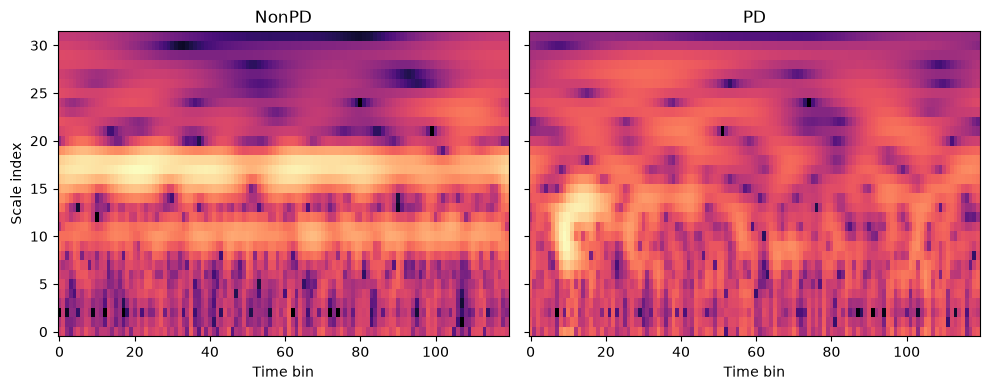

In [2]:
def fit_standardizer(values):
    mean = values.mean(axis=0, keepdims=True).astype(np.float32)
    std = values.std(axis=0, keepdims=True).astype(np.float32); std[std < 1e-6] = 1.0
    return mean, std

CWT_W0, CWT_SCALES, CWT_TIME_BINS, CWT_FLOOR, CWT_EPS = 6.0, np.geomspace(1.5, 64.0, 32).astype(np.float32), 120, -10.0, 1e-8
CWT_INDEX = np.linspace(0, 399, CWT_TIME_BINS).round().astype(int); CWT_SHAPE = (len(CWT_SCALES), CWT_TIME_BINS)

def cwt_log_batch(values):
    values = np.asarray(values, dtype=np.float32); signal_fft = np.fft.fft(values, axis=1)
    centered = np.arange(400, dtype=np.float64) - 200; result = np.empty((len(values), *CWT_SHAPE), dtype=np.float32)
    for scale_index, scale in enumerate(CWT_SCALES.astype(np.float64)):
        wavelet = np.exp(-0.5 * (centered / scale) ** 2) * np.exp(1j * CWT_W0 * centered / scale) / np.sqrt(scale)
        coefficients = np.fft.ifft(signal_fft * np.conj(np.fft.fft(np.fft.ifftshift(wavelet)))[None, :], axis=1)
        result[:, scale_index, :] = np.maximum(np.log(np.abs(coefficients[:, CWT_INDEX]) ** 2 + CWT_EPS), CWT_FLOOR)
    return result.astype(np.float32)

X_fitval, y_fitval = np.concatenate([X_train, X_val]), np.concatenate([y_train, y_val])
fit_indices = np.arange(len(X_train), dtype=np.int64); stop_indices = np.arange(len(X_train), len(X_fitval), dtype=np.int64)
raw_mean, raw_std = fit_standardizer(X_train)
cwt_path = RESULT_DIR / 'poc3_cwt_tr0_va0_log_float16.dat'; cwt_meta_path = RESULT_DIR / 'poc3_cwt_tr0_va0_cache_meta.json'
cwt_meta = {'shape': [len(X_fitval), CWT_SHAPE[0], CWT_SHAPE[1]], 'dtype': 'float16', 'wavelet': 'complex Morlet', 'morlet_w0': CWT_W0, 'scales': [float(x) for x in CWT_SCALES], 'time_bins': CWT_TIME_BINS, 'clip_floor': CWT_FLOOR, 'source': 'Tr0/Va0 only'}
valid_cache = False
if cwt_path.is_file() and cwt_meta_path.is_file():
    try: valid_cache = json.loads(cwt_meta_path.read_text()) == cwt_meta
    except Exception: pass
if valid_cache:
    cwt_cache = np.memmap(cwt_path, dtype=np.float16, mode='r+', shape=tuple(cwt_meta['shape'])); print('Reusing CWT cache.')
else:
    cwt_cache = np.memmap(cwt_path, dtype=np.float16, mode='w+', shape=tuple(cwt_meta['shape']))
    for start in range(0, len(X_fitval), 1024):
        stop = min(start + 1024, len(X_fitval)); cwt_cache[start:stop] = cwt_log_batch(X_fitval[start:stop]).astype(np.float16)
    cwt_cache.flush(); cwt_meta_path.write_text(json.dumps(cwt_meta, indent=2, sort_keys=True)); print('Generated CWT cache.')

def fit_cwt_standardizer(cache, indices, chunk_size=2048):
    total = np.zeros(CWT_SHAPE, dtype=np.float64); total_sq = np.zeros(CWT_SHAPE, dtype=np.float64); indices = np.asarray(indices, dtype=np.int64)
    for start in range(0, len(indices), chunk_size):
        batch = np.asarray(cache[indices[start:start + chunk_size]], dtype=np.float32); total += batch.sum(axis=0); total_sq += np.square(batch, dtype=np.float64).sum(axis=0)
    mean = total / len(indices); variance = np.maximum(total_sq / len(indices) - mean * mean, 1e-6)
    return mean.astype(np.float32), np.sqrt(variance).astype(np.float32)

cwt_mean, cwt_std = fit_cwt_standardizer(cwt_cache, fit_indices)
fig, axes = plt.subplots(1, 2, figsize=(10, 4), sharey=True)
for ax, index, title in zip(axes, [0, len(X_train)], ['NonPD', 'PD']): ax.imshow(np.asarray(cwt_cache[index]), origin='lower', aspect='auto', cmap='magma'); ax.set_title(title); ax.set_xlabel('Time bin')
axes[0].set_ylabel('Scale index'); fig.tight_layout(); fig.savefig(RESULT_DIR / 'poc3_cwt_examples.png', dpi=140); display(fig); plt.close(fig)

## Same temporal expert/training design as PoC-1

The temporal CNN layers, Adam settings, batch size, seed, patience, and
checkpoint rule match PoC-1. The CWT branch uses the same training settings but
necessarily has a 2D convolutional input architecture.

In [3]:
class TinyTemporalCNN(nn.Module):
    def __init__(self):
        super().__init__(); self.features = nn.Sequential(nn.Conv1d(1,16,7,padding=3),nn.BatchNorm1d(16),nn.ReLU(),nn.MaxPool1d(2),nn.Conv1d(16,32,5,padding=2),nn.BatchNorm1d(32),nn.ReLU(),nn.MaxPool1d(2),nn.Conv1d(32,64,5,padding=2),nn.BatchNorm1d(64),nn.ReLU(),nn.AdaptiveAvgPool1d(1)); self.classifier = nn.Linear(64,1)
    def forward(self, x): return self.classifier(self.features(x).squeeze(-1)).squeeze(-1)

class SmallCWT2DCNN(nn.Module):
    def __init__(self):
        super().__init__(); self.features = nn.Sequential(nn.Conv2d(1,16,3,padding=1),nn.BatchNorm2d(16),nn.ReLU(),nn.MaxPool2d(2),nn.Conv2d(16,32,3,padding=1),nn.BatchNorm2d(32),nn.ReLU(),nn.MaxPool2d(2),nn.Conv2d(32,64,3,padding=1),nn.BatchNorm2d(64),nn.ReLU(),nn.AdaptiveAvgPool2d(1)); self.classifier = nn.Linear(64,1)
    def forward(self, x): return self.classifier(self.features(x).flatten(1)).squeeze(-1)

class TemporalDataset(Dataset):
    def __init__(self, signals, labels, indices, mean, std): self.signals,self.labels,self.indices,self.mean,self.std=signals,labels,np.asarray(indices,dtype=np.int64),mean,std
    def __len__(self): return len(self.indices)
    def __getitem__(self, i):
        j=int(self.indices[i]); return torch.from_numpy(((self.signals[j:j+1]-self.mean)/self.std).astype(np.float32)), torch.tensor(float(self.labels[j]),dtype=torch.float32)

class CWTDataset(Dataset):
    def __init__(self, cache, labels, indices, mean, std): self.cache,self.labels,self.indices,self.mean,self.std=cache,labels,np.asarray(indices,dtype=np.int64),mean.astype(np.float32),std.astype(np.float32)
    def __len__(self): return len(self.indices)
    def __getitem__(self, i):
        j=int(self.indices[i]); x=((np.asarray(self.cache[j],dtype=np.float32)-self.mean)/self.std).astype(np.float32); return torch.from_numpy(x[None]), torch.tensor(float(self.labels[j]),dtype=torch.float32)

def dataset_for(kind, signals, labels, cache, indices, rmean, rstd, cmean, cstd):
    return TemporalDataset(signals,labels,indices,rmean,rstd) if kind=='temporal' else CWTDataset(cache,labels,indices,cmean,cstd)

def model_for(kind): return (TinyTemporalCNN() if kind=='temporal' else SmallCWT2DCNN()).to(DEVICE)
def params(model): return int(sum(p.numel() for p in model.parameters() if p.requires_grad))

def predict_logits(model, dataset):
    loader=DataLoader(dataset,batch_size=INFERENCE_BATCH_SIZE,shuffle=False,num_workers=0); model.eval(); values=[]
    with torch.no_grad():
        for x,_ in loader: values.append(model(x.to(DEVICE)).detach().cpu().numpy())
    return np.concatenate(values).astype(np.float64)

def train_expert(kind, signals, labels, cache, train_idx, stop_idx, rmean, rstd, cmean, cstd, seed):
    random.seed(seed); np.random.seed(seed); torch.manual_seed(seed); model=model_for(kind)
    train_ds=dataset_for(kind,signals,labels,cache,train_idx,rmean,rstd,cmean,cstd); stop_ds=dataset_for(kind,signals,labels,cache,stop_idx,rmean,rstd,cmean,cstd)
    loader=DataLoader(train_ds,batch_size=BATCH_SIZE,shuffle=True,generator=torch.Generator().manual_seed(seed),num_workers=0); opt=torch.optim.Adam(model.parameters(),lr=1e-3,weight_decay=1e-4); loss_fn=nn.BCEWithLogitsLoss(); best_state=None; best_mcc=-np.inf; best_epoch=1; stale=0; history=[]
    for epoch in range(1,MAX_EPOCHS+1):
        model.train(); losses=[]
        for x,y in loader: opt.zero_grad(set_to_none=True); loss=loss_fn(model(x.to(DEVICE)),y.to(DEVICE)); loss.backward(); opt.step(); losses.append(float(loss.detach().cpu()))
        stop_logits=predict_logits(model,stop_ds); score=float(matthews_corrcoef(labels[stop_idx],stop_logits>=0)); history.append({'epoch':epoch,'train_loss':float(np.mean(losses)),'val_mcc_at_0.5':score})
        if score>best_mcc+1e-12: best_mcc,best_epoch,stale=score,epoch,0; best_state={k:v.detach().cpu().clone() for k,v in model.state_dict().items()}
        else: stale+=1
        if stale>=PATIENCE: break
    model.load_state_dict(best_state); return model,history,best_epoch

## Leakage-safe gate fit and validation-only selection

The final experts follow PoC-1 exactly: fit on `Tr0`, stop on `Va0`. The gate
is learned from five-fold nested OOF predictions generated inside `Tr0` and is
selected on `Va0`. Fixed mean, entropy, and fixed-weight baselines use only
validation thresholds.

In [4]:
gate_cv = StratifiedKFold(n_splits=N_GATE_FOLDS, shuffle=True, random_state=SEED)
train_cwt = cwt_cache[:len(X_train)]
oof_t, oof_c = np.full(len(y_train), np.nan), np.full(len(y_train), np.nan)
fold_assignment = np.full(len(y_train), -1, dtype=np.int64)
gate_histories, gate_records = {'temporal': {}, 'cwt': {}}, []
for fold_id, (outer_fit, outer_holdout) in enumerate(gate_cv.split(X_train, y_train), 1):
    inner_fit, inner_stop = train_test_split(outer_fit, test_size=0.10, stratify=y_train[outer_fit], random_state=SEED + fold_id)
    fold_assignment[outer_holdout] = fold_id
    rm, rs = fit_standardizer(X_train[inner_fit]); cm, cs = fit_cwt_standardizer(train_cwt, inner_fit)
    for kind in ['temporal', 'cwt']:
        model, history, best_epoch = train_expert(kind, X_train, y_train, train_cwt, inner_fit, inner_stop, rm, rs, cm, cs, SEED + 100 * fold_id + (0 if kind == 'temporal' else 1))
        values = predict_logits(model, dataset_for(kind, X_train, y_train, train_cwt, outer_holdout, rm, rs, cm, cs))
        (oof_t if kind == 'temporal' else oof_c)[outer_holdout] = values
        gate_histories[kind][str(fold_id)] = history
        gate_records.append({'fold_id': fold_id, 'expert': kind, 'best_epoch': best_epoch, 'outer_fit_n': len(outer_fit), 'inner_fit_n': len(inner_fit), 'inner_stop_n': len(inner_stop)})
        print(f'fold {fold_id}/{N_GATE_FOLDS} {kind}: best_epoch={best_epoch}')
        del model; gc.collect()
assert np.isfinite(oof_t).all() and np.isfinite(oof_c).all()

temporal_model, temporal_history, temporal_best_epoch = train_expert('temporal', X_fitval, y_fitval, cwt_cache, fit_indices, stop_indices, raw_mean, raw_std, cwt_mean, cwt_std, SEED)
cwt_model, cwt_history, cwt_best_epoch = train_expert('cwt', X_fitval, y_fitval, cwt_cache, fit_indices, stop_indices, raw_mean, raw_std, cwt_mean, cwt_std, SEED)
val_t = predict_logits(temporal_model, TemporalDataset(X_fitval, y_fitval, stop_indices, raw_mean, raw_std))
val_c = predict_logits(cwt_model, CWTDataset(cwt_cache, y_fitval, stop_indices, cwt_mean, cwt_std))

def sigmoid(x): return 1.0 / (1.0 + np.exp(-np.clip(x, -40, 40)))
def fit_temperature(logits, labels):
    grid = np.exp(np.linspace(np.log(.25), np.log(4.0), 81)); losses = [np.mean(np.logaddexp(0, logits/t) - labels*(logits/t)) for t in grid]; return float(grid[int(np.argmin(losses))])
def select_threshold(labels, prob):
    grid = np.linspace(.05, .95, 181); scores = [matthews_corrcoef(labels, prob >= t) for t in grid]; best = max(scores); ties = grid[np.isclose(scores, best)]; return float(ties[np.argmin(np.abs(ties-.5))])
def entropy(prob):
    prob = np.clip(prob, 1e-7, 1-1e-7); return -(prob*np.log2(prob) + (1-prob)*np.log2(1-prob))
def fuse_entropy(t, c):
    w = np.column_stack([1-entropy(t), 1-entropy(c)]) + 1e-6; w /= w.sum(axis=1, keepdims=True); return w[:,0]*t + w[:,1]*c

temp_t, temp_c = fit_temperature(val_t, y_val), fit_temperature(val_c, y_val)
val_tp, val_cp = sigmoid(val_t/temp_t), sigmoid(val_c/temp_c)
th_t, th_c = select_threshold(y_val, val_tp), select_threshold(y_val, val_cp)
val_mean, val_ent = .5*(val_tp+val_cp), fuse_entropy(val_tp, val_cp)
th_mean, th_ent = select_threshold(y_val, val_mean), select_threshold(y_val, val_ent)
weight_rows = []
for w in np.linspace(0, 1, 51):
    p = w*val_tp + (1-w)*val_cp; th = select_threshold(y_val, p); weight_rows.append((matthews_corrcoef(y_val, p >= th), w, th))
_, fixed_weight, th_weight = max(weight_rows, key=lambda row: (row[0], -abs(row[1]-.5)))

def gate_features(t, c):
    tp, cp = sigmoid(t/temp_t), sigmoid(c/temp_c); tpred, cpred = (tp >= th_t).astype(int), (cp >= th_c).astype(int)
    return np.column_stack([t, c, tp, cp, abs(t-c), abs(tp-cp), abs(tp-.5), abs(cp-.5), entropy(tp), entropy(cp), tpred, cpred, tpred != cpred, tp*cp, 1-(1-tp)*(1-cp), np.minimum(tp,cp), np.maximum(tp,cp)]).astype(np.float64)

foof, fval = gate_features(oof_t, oof_c), gate_features(val_t, val_c)
poof_t, poof_c = foof[:,10].astype(int), foof[:,11].astype(int); pval_t, pval_c = fval[:,10].astype(int), fval[:,11].astype(int)
doof, dval = poof_t != poof_c, pval_t != pval_c
gate_models = {'logistic': Pipeline([('scale', StandardScaler()), ('model', LogisticRegression(max_iter=1000, random_state=SEED, class_weight='balanced'))]), 'small_mlp': Pipeline([('scale', StandardScaler()), ('model', MLPClassifier(hidden_layer_sizes=(16,8), activation='relu', solver='adam', alpha=1e-3, batch_size=128, learning_rate_init=1e-3, max_iter=250, early_stopping=True, validation_fraction=.2, n_iter_no_change=15, random_state=SEED))])}
selection=[]; selected_model=selected_name=selected_tau=None; selected_val_mcc=-np.inf; selected_harmful=10**9
for name, model in gate_models.items():
    model.fit(foof[doof], y_train[doof] == poof_c[doof]); score = model.predict_proba(fval[dval])[:,1]; full_score = np.zeros(len(y_val), dtype=np.float64); full_score[dval] = score
    for tau in np.linspace(.5,.95,91):
        pred=pval_t.copy(); override=dval & (full_score >= tau); pred[override]=pval_c[override]; mcc=float(matthews_corrcoef(y_val,pred)); harmful=int(np.sum(override & (pval_t==y_val) & (pval_c!=y_val))); beneficial=int(np.sum(override & (pval_t!=y_val) & (pval_c==y_val))); selection.append({'model':name,'tau':float(tau),'mcc':mcc,'overrides':int(override.sum()),'beneficial':beneficial,'harmful':harmful})
        if (mcc, -tau, -harmful) > (selected_val_mcc, -(selected_tau or 0), -selected_harmful): selected_model,selected_name,selected_tau,selected_val_mcc,selected_harmful=model,name,float(tau),mcc,harmful
gate_selection=pd.DataFrame(selection)
print('Temporal/CWT best epochs:', temporal_best_epoch, cwt_best_epoch); print('Temperatures:', temp_t, temp_c); print('Thresholds:', th_t, th_c, th_mean, th_ent); print('Selected gate:', selected_name, selected_tau, 'Va0 MCC=', selected_val_mcc)
display(gate_selection.sort_values('mcc', ascending=False).head(10))

fold 1/5 temporal: best_epoch=6


fold 1/5 cwt: best_epoch=7


fold 2/5 temporal: best_epoch=2


fold 2/5 cwt: best_epoch=13


fold 3/5 temporal: best_epoch=5


...

fold 4/5 cwt: best_epoch=2


fold 5/5 temporal: best_epoch=5


fold 5/5 cwt: best_epoch=6


Temporal/CWT best epochs: 9 5
Temperatures: 0.7071067811865475 0.5176324619206888
Thresholds: 0.245 0.5549999999999999 0.3549999999999999 0.26499999999999996
Selected gate: small_mlp 0.69 Va0 MCC= 0.9578491534063076


,model,tau,mcc,overrides,beneficial,harmful
130,small_mlp,0.695,0.957849,29,24,5
129,small_mlp,0.690,0.957849,29,24,5
44,logistic,0.720,0.957183,22,20,2
45,logistic,0.725,0.957183,22,20,2
43,logistic,0.715,0.957183,22,20,2
46,logistic,0.730,0.957183,22,20,2
125,small_mlp,0.670,0.957156,32,25,7
127,small_mlp,0.680,0.957156,32,25,7
126,small_mlp,0.675,0.957156,32,25,7
128,small_mlp,0.685,0.957156,32,25,7


# FINAL LOCKED EVALUATION — NO FURTHER MODEL SELECTION AFTER THIS POINT

The next cell is the first and only load of `Te0.mat`. `Te1.mat` and `Te2.mat`
remain untouched. All models, gate candidates, thresholds, and verdict rules
are frozen above.

In [5]:
X_test, y_test = load_partition('Te0.mat')
test_cwt_path = RESULT_DIR / 'poc3_cwt_te0_log_float16.dat'; test_cwt_meta_path = RESULT_DIR / 'poc3_cwt_te0_cache_meta.json'
test_meta = {'shape': [len(X_test), CWT_SHAPE[0], CWT_SHAPE[1]], 'dtype': 'float16', 'wavelet': 'complex Morlet', 'morlet_w0': CWT_W0, 'scales': [float(x) for x in CWT_SCALES], 'time_bins': CWT_TIME_BINS, 'clip_floor': CWT_FLOOR, 'source': 'Te0 only; created after lock'}
test_cwt = np.memmap(test_cwt_path, dtype=np.float16, mode='w+', shape=tuple(test_meta['shape']))
for start in range(0, len(X_test), 1024):
    stop = min(start+1024, len(X_test)); test_cwt[start:stop] = cwt_log_batch(X_test[start:stop]).astype(np.float16)
test_cwt.flush(); test_cwt_meta_path.write_text(json.dumps(test_meta, indent=2, sort_keys=True))
test_idx = np.arange(len(X_test), dtype=np.int64)
test_t = predict_logits(temporal_model, TemporalDataset(X_test,y_test,test_idx,raw_mean,raw_std)); test_c = predict_logits(cwt_model,CWTDataset(test_cwt,y_test,test_idx,cwt_mean,cwt_std))
test_tp, test_cp = sigmoid(test_t/temp_t), sigmoid(test_c/temp_c); test_pt, test_pc = (test_tp>=th_t).astype(int), (test_cp>=th_c).astype(int)
test_mean, test_ent, test_weight = .5*(test_tp+test_cp), fuse_entropy(test_tp,test_cp), fixed_weight*test_tp+(1-fixed_weight)*test_cp
test_pm, test_pe, test_pw = (test_mean>=th_mean).astype(int), (test_ent>=th_ent).astype(int), (test_weight>=th_weight).astype(int)
ftest = gate_features(test_t,test_c); test_disagreement = ftest[:,10].astype(int) != ftest[:,11].astype(int); test_gate_score_disagreement = selected_model.predict_proba(ftest[test_disagreement])[:,1]; test_gate_score_full = np.zeros(len(y_test), dtype=np.float64); test_gate_score_full[test_disagreement] = test_gate_score_disagreement
test_gate_pred = test_pt.copy(); test_override = test_disagreement & (test_gate_score_full>=selected_tau); test_gate_pred[test_override] = test_pc[test_override]
test_gate_score = np.where(test_override,test_cp,test_tp)
print('Locked Te0:', X_test.shape, '| disagreements:', int(test_disagreement.sum()), '| gate overrides:', int(test_override.sum()))

def ece(labels, prob, bins=10):
    edges=np.linspace(0,1,bins+1); value=0.0
    for lo,hi in zip(edges[:-1],edges[1:]):
        mask=(prob>=lo)&(prob < hi if hi<1 else prob<=hi)
        if mask.any(): value += mask.mean()*abs(prob[mask].mean()-labels[mask].mean())
    return float(value)
def evaluate(labels, pred, score, threshold):
    tn,fp,fn,tp=confusion_matrix(labels,pred,labels=[0,1]).ravel(); score=np.clip(score,0,1)
    return {'threshold':float(threshold),'mcc':float(matthews_corrcoef(labels,pred)),'f1':float(f1_score(labels,pred,zero_division=0)),'accuracy':float(accuracy_score(labels,pred)),'precision':float(precision_score(labels,pred,zero_division=0)),'recall_tpr':float(recall_score(labels,pred,zero_division=0)),'specificity':float(tn/(tn+fp)),'fpr':float(fp/(fp+tn)),'roc_auc':float(roc_auc_score(labels,score)),'pr_auc':float(average_precision_score(labels,score)),'brier':float(brier_score_loss(labels,score)),'ece_10_bins':ece(labels,score),'tn':int(tn),'fp':int(fp),'fn':int(fn),'tp':int(tp)}
test_metrics={'Temporal (PoC-1 matched)':evaluate(y_test,test_pt,test_tp,th_t),'CWT':evaluate(y_test,test_pc,test_cp,th_c),'Fixed mean':evaluate(y_test,test_pm,test_mean,th_mean),'Entropy adaptive':evaluate(y_test,test_pe,test_ent,th_ent),'Optimal fixed weight':evaluate(y_test,test_pw,test_weight,th_weight),'Conservative gate':evaluate(y_test,test_gate_pred,test_gate_score,selected_tau)}
display(pd.DataFrame(test_metrics).T[['mcc','accuracy','precision','recall_tpr','f1','pr_auc','roc_auc','brier','ece_10_bins']].sort_values('mcc',ascending=False))

Locked Te0: (45970, 400) | disagreements: 1616 | gate overrides: 428


,mcc,accuracy,precision,recall_tpr,f1,pr_auc,roc_auc,brier,ece_10_bins
Conservative gate,0.957425,0.978573,0.990415,0.966500,0.978311,0.996140,0.995517,0.024215,0.020047
Optimal fixed weight,0.957234,0.978529,0.987847,0.968980,0.978322,0.997770,0.997441,0.021975,0.026473
Entropy adaptive,0.955520,0.977703,0.985197,0.969980,0.977529,0.997634,0.997288,0.018978,0.015296
Fixed mean,0.952220,0.976093,0.980167,0.971851,0.975991,0.997729,0.997430,0.020100,0.021011
Temporal (PoC-1 matched),0.948920,0.974309,0.986566,0.961714,0.973982,0.996424,0.995773,0.025681,0.022904
CWT,0.934178,0.966957,0.978340,0.955058,0.966559,0.995606,0.995262,0.024668,0.003686


## Locked statistical comparison

Bootstrap: {'cwt_minus_temporal': {'comparison': 'CWT minus Temporal', 'point_estimate': -0.014741786653231226, 'ci_95': [-0.01808810360307412, -0.0111628204959821], 'fraction_gt_zero': 0.0, 'n_bootstrap': 2000}, 'gate_minus_temporal': {'comparison': 'Gate minus Temporal', 'point_estimate': 0.008505330907449538, 'ci_95': [0.0067525846659748, 0.010203008336523087], 'fraction_gt_zero': 1.0, 'n_bootstrap': 2000}, 'gate_minus_cwt': {'comparison': 'Gate minus CWT', 'point_estimate': 0.023247117560680763, 'ci_95': [0.020376887769728073, 0.026078781257917523], 'fraction_gt_zero': 1.0, 'n_bootstrap': 2000}}
McNemar: {'gate_vs_temporal': {'b_baseline_correct_fusion_wrong': 116, 'c_baseline_wrong_fusion_correct': 312, 'exact_two_sided_p_value': 7.96340263228165e-22, 'chi_square_with_continuity_correction': 88.84345794392523}, 'gate_vs_cwt': {'b_baseline_correct_fusion_wrong': 327, 'c_baseline_wrong_fusion_correct': 861, 'exact_two_sided_p_value': 7.662943705057724e-56, 'chi_square_with_continuit

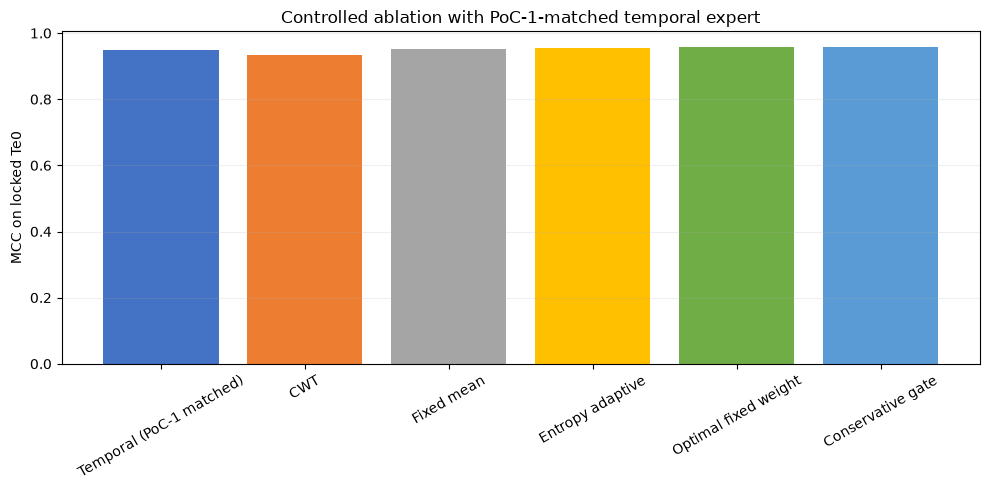

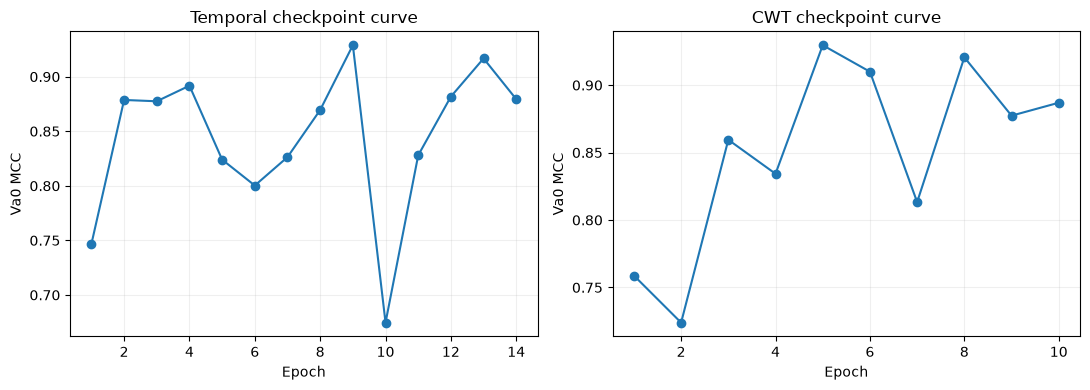

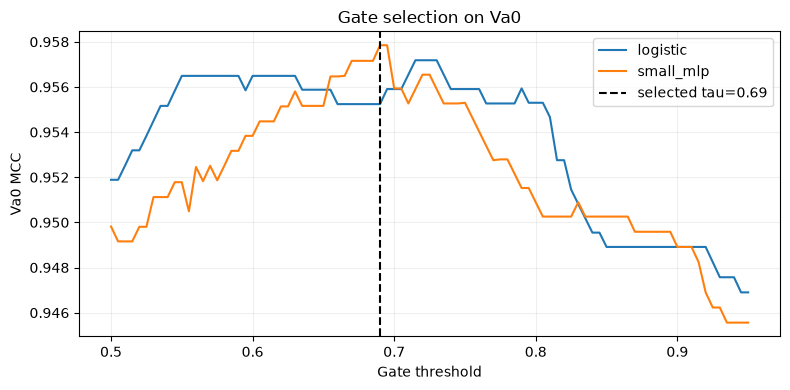

In [6]:
def mcc_fast(labels, pred):
    labels, pred = np.asarray(labels, dtype=np.int64), np.asarray(pred, dtype=np.int64)
    tp=int(np.sum((labels==1)&(pred==1))); tn=int(np.sum((labels==0)&(pred==0))); fp=int(np.sum((labels==0)&(pred==1))); fn=int(np.sum((labels==1)&(pred==0)))
    den=math.sqrt((tp+fp)*(tp+fn)*(tn+fp)*(tn+fn)); return float((tp*tn-fp*fn)/den) if den else 0.0

def bootstrap_delta(pred_a, pred_b, seed):
    rng=np.random.default_rng(seed); values=np.empty(N_BOOTSTRAP)
    for i in range(N_BOOTSTRAP):
        idx=rng.integers(0,len(y_test),len(y_test)); values[i]=mcc_fast(y_test[idx],pred_a[idx])-mcc_fast(y_test[idx],pred_b[idx])
    return values

boot_ct=bootstrap_delta(test_pc,test_pt,BOOTSTRAP_SEED+1); boot_gt=bootstrap_delta(test_gate_pred,test_pt,BOOTSTRAP_SEED+2); boot_gc=bootstrap_delta(test_gate_pred,test_pc,BOOTSTRAP_SEED+3)
def boot_summary(name, values):
    return {'comparison':name,'point_estimate':float(values.mean()*0 + np.quantile(values,.5)),'ci_95':[float(np.quantile(values,.025)),float(np.quantile(values,.975))],'fraction_gt_zero':float(np.mean(values>0)),'n_bootstrap':N_BOOTSTRAP}
bootstrap_results={'cwt_minus_temporal':boot_summary('CWT minus Temporal',boot_ct),'gate_minus_temporal':boot_summary('Gate minus Temporal',boot_gt),'gate_minus_cwt':boot_summary('Gate minus CWT',boot_gc)}
bootstrap_results['cwt_minus_temporal']['point_estimate']=test_metrics['CWT']['mcc']-test_metrics['Temporal (PoC-1 matched)']['mcc']
bootstrap_results['gate_minus_temporal']['point_estimate']=test_metrics['Conservative gate']['mcc']-test_metrics['Temporal (PoC-1 matched)']['mcc']
bootstrap_results['gate_minus_cwt']['point_estimate']=test_metrics['Conservative gate']['mcc']-test_metrics['CWT']['mcc']
pd.DataFrame({'cwt_minus_temporal':boot_ct,'gate_minus_temporal':boot_gt,'gate_minus_cwt':boot_gc}).to_csv(RESULT_DIR/'poc3_bootstrap_deltas.csv',index=False)

def paired_mcnemar(fusion, baseline):
    fusion_correct, base_correct = fusion==y_test, baseline==y_test; b=int(np.sum(base_correct & ~fusion_correct)); c=int(np.sum(~base_correct & fusion_correct)); total=b+c
    exact=float(binomtest(min(b,c),total,.5,alternative='two-sided').pvalue) if total else 1.0; chi=float((abs(b-c)-1)**2/total) if total else 0.0
    return {'b_baseline_correct_fusion_wrong':b,'c_baseline_wrong_fusion_correct':c,'exact_two_sided_p_value':exact,'chi_square_with_continuity_correction':chi}

mcnemar_results={'gate_vs_temporal':paired_mcnemar(test_gate_pred,test_pt),'gate_vs_cwt':paired_mcnemar(test_gate_pred,test_pc)}
checks={name: value['ci_95'][0]>0 for name,value in bootstrap_results.items()}; overall_verdict='GO' if all(checks.values()) else 'REVISE'
reason='Gate improves CWT and temporal with positive bootstrap lower bounds.' if overall_verdict=='GO' else 'Gate does not improve every individual comparator under the controlled protocol.'
print('Bootstrap:',bootstrap_results); print('McNemar:',mcnemar_results); print('Decision:',overall_verdict,'|',reason)

fig,ax=plt.subplots(figsize=(10,5)); names=list(test_metrics); ax.bar(names,[test_metrics[n]['mcc'] for n in names],color=['#4472c4','#ed7d31','#a5a5a5','#ffc000','#70ad47','#5b9bd5']); ax.set_ylabel('MCC on locked Te0'); ax.set_title('Controlled ablation with PoC-1-matched temporal expert'); ax.tick_params(axis='x',rotation=30); ax.grid(axis='y',alpha=.2); fig.tight_layout(); fig.savefig(RESULT_DIR/'poc3_controlled_mcc.png',dpi=140); display(fig); plt.close(fig)
fig,axes=plt.subplots(1,2,figsize=(11,4));
for ax,hist,name in [(axes[0],temporal_history,'Temporal'),(axes[1],cwt_history,'CWT')]:
    frame=pd.DataFrame(hist); ax.plot(frame['epoch'],frame['val_mcc_at_0.5'],marker='o'); ax.set_title(name+' checkpoint curve'); ax.set_xlabel('Epoch'); ax.set_ylabel('Va0 MCC'); ax.grid(alpha=.2)
fig.tight_layout(); fig.savefig(RESULT_DIR/'poc3_training_curves.png',dpi=140); display(fig); plt.close(fig)
fig,ax=plt.subplots(figsize=(8,4));
for name,group in gate_selection.groupby('model'): ax.plot(group['tau'],group['mcc'],label=name)
ax.axvline(selected_tau,color='black',linestyle='--',label=f'selected tau={selected_tau:.2f}'); ax.set_xlabel('Gate threshold'); ax.set_ylabel('Va0 MCC'); ax.set_title('Gate selection on Va0'); ax.legend(); ax.grid(alpha=.2); fig.tight_layout(); fig.savefig(RESULT_DIR/'poc3_gate_threshold_sweep.png',dpi=140); display(fig); plt.close(fig)

In [7]:
oof_frame=pd.DataFrame({'sample_id':[f'Tr0:{i:08d}' for i in range(len(y_train))],'partition':'Tr0','true_label':y_train.astype(int),'fold_id':fold_assignment,'temporal_logit_oof':oof_t,'cwt_logit_oof':oof_c,'temporal_prediction_oof':poof_t,'cwt_prediction_oof':poof_c})
oof_frame.to_csv(RESULT_DIR/'poc3_gate_oof_predictions.csv',index=False)
test_frame=pd.DataFrame({'sample_id':[f'Te0:{i:08d}' for i in range(len(y_test))],'true_label':y_test.astype(int),'temporal_probability':test_tp,'cwt_probability':test_cp,'temporal_prediction':test_pt,'cwt_prediction':test_pc,'fixed_mean_prediction':test_pm,'entropy_prediction':test_pe,'fixed_weight_prediction':test_pw,'override':test_override.astype(int),'gate_prediction':test_gate_pred})
test_frame.to_csv(RESULT_DIR/'poc3_te0_predictions.csv',index=False)

poc1_reference={}
old_summary=RESULT_DIR/'summary.json'
if old_summary.is_file():
    try: poc1_reference=json.loads(old_summary.read_text()).get('metrics_on_Te0',{}).get('temporal',{})
    except Exception: poc1_reference={}
artifact_names=['poc3_results.json','poc3_gate_oof_predictions.csv','poc3_te0_predictions.csv','poc3_bootstrap_deltas.csv','poc3_cwt_tr0_va0_log_float16.dat','poc3_cwt_tr0_va0_cache_meta.json','poc3_cwt_te0_log_float16.dat','poc3_cwt_te0_cache_meta.json','poc3_cwt_examples.png','poc3_controlled_mcc.png','poc3_training_curves.png','poc3_gate_threshold_sweep.png']
results={'poc':'poc3-controlled-cwt-ablation','objective':'Controlled isolation of CWT and gate contributions under the PoC-1 split and temporal expert configuration.','protocol':{'train':'Tr0.mat','validation':'Va0.mat','locked_test':'Te0.mat','untouched':['Te1.mat','Te2.mat'],'te0_loaded_only_after_lock':True},'controlled_design':{'temporal_architecture':'PoC-1 TinyCNN1D, unchanged layers','temporal_input':'standardized raw signal, 400 samples','seed':SEED,'max_epochs':MAX_EPOCHS,'patience':PATIENCE,'batch_size':BATCH_SIZE,'torch_threads':TORCH_THREADS,'optimizer':'Adam(lr=1e-3, weight_decay=1e-4)','loss':'BCEWithLogitsLoss','gate_training':'five-fold nested OOF predictions on Tr0; model/tau selected on Va0'},'experts':{'temporal':{'best_epoch':temporal_best_epoch,'parameters':params(temporal_model)},'cwt':{'best_epoch':cwt_best_epoch,'parameters':params(cwt_model)},'poc1_saved_temporal_te0_metrics':poc1_reference},'selection':{'temperature_temporal':temp_t,'temperature_cwt':temp_c,'threshold_temporal':th_t,'threshold_cwt':th_c,'threshold_fixed_mean':th_mean,'threshold_entropy':th_ent,'fixed_weight':fixed_weight,'threshold_fixed_weight':th_weight,'gate_model':selected_name,'gate_tau':selected_tau,'gate_va0_mcc':selected_val_mcc},'final_te0_metrics':test_metrics,'mcc_deltas':{'cwt_minus_temporal':test_metrics['CWT']['mcc']-test_metrics['Temporal (PoC-1 matched)']['mcc'],'gate_minus_temporal':test_metrics['Conservative gate']['mcc']-test_metrics['Temporal (PoC-1 matched)']['mcc'],'gate_minus_cwt':test_metrics['Conservative gate']['mcc']-test_metrics['CWT']['mcc']},'bootstrap':bootstrap_results,'mcnemar':mcnemar_results,'decision':{'checks':checks,'overall_verdict':overall_verdict,'reason':reason},'provenance':{'dataset_id':DATASET_ID,'dataset_version':DATASET_VERSION,'catalog_root_from_environment':'PD_DATASETS_CATALOG_ROOT','python':sys.version,'numpy':np.__version__,'pandas':pd.__version__,'torch':torch.__version__,'repository_commit':git_commit(),'te1_or_te2_loaded':False,'artifacts':artifact_names}}
(RESULT_DIR/'poc3_results.json').write_text(json.dumps(results,indent=2,sort_keys=True))
assert all((RESULT_DIR/name).exists() for name in artifact_names)
print('Saved controlled PoC results:',RESULT_DIR/'poc3_results.json')

Saved controlled PoC results: /home/polivares/Dropbox/Work/researchhub-atlas-polivares/workspaces/PRJ-2026-003-partial-discharge-adaptive-fusion/poc/results/poc3_results.json
